# 🎙️ Bengali Audio Deepfake Detection - Data Preprocessing & Analysis

This notebook provides comprehensive data analysis, visualization, and preprocessing for the Bengali Audio Deepfake Detection project.

## Contents:
1. **Environment Setup & Imports**
2. **Dataset Loading & Structure Analysis**
3. **Audio Statistics & Properties**
4. **Waveform Visualization**
5. **Spectral Analysis (Spectrograms, Mel-Spectrograms)**
6. **MFCC Feature Analysis**
7. **Dataset Balance & Distribution**
8. **Stratified Train/Val/Test Split (70/15/15)**
9. **Data Export for Training Pipeline**


---
## 1. Environment Setup & Imports


In [76]:
# Install required packages (uncomment if needed)
# %pip install librosa matplotlib seaborn pandas numpy scikit-learn tqdm soundfile ipywidgets


In [77]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from IPython.display import Audio, display

# Set visual styles
plt.style.use('dark_background')
sns.set_palette('husl')

# Class names and colors (1 real + 3 fake)
CLASS_NAMES = ['real_samples', 'baglafake_deepfake', 'crikk_deepfake', 'gemini_deepfake']
CLASS_COLORS = {
    'real_samples': '#00D4AA',
    'baglafake_deepfake': '#FF6B6B',
    'crikk_deepfake': '#F59E0B',
    'gemini_deepfake': '#60A5FA',
    'accent': '#A78BFA',
    'bg': '#1a1a2e'
}

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [78]:
# Resolve dataset and visualization paths
DATA_PATH_CANDIDATES = [Path('./Data'), Path('../Data')]
BASE_DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), DATA_PATH_CANDIDATES[0])

VISUALIZATION_DIR = Path('./Visualization')
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename: str):
    """Save current matplotlib figure into the parent Visualization directory."""
    plt.savefig(
        VISUALIZATION_DIR / filename,
        dpi=150,
        bbox_inches='tight',
        facecolor='#1a1a2e'
    )

print(f"Using data directory: {BASE_DATA_PATH.resolve()}")
print(f"Saving plots to: {VISUALIZATION_DIR.resolve()}")

for class_name in CLASS_NAMES:
    class_path = BASE_DATA_PATH / class_name
    exists = class_path.exists()
    print(f"{class_name:20s} | Path: {class_path} | Exists: {'✅' if exists else '❌'}")

Using data directory: F:\ML Project\Bangla Audio Deepfake Detection\Data Augmentation\Data
Saving plots to: F:\ML Project\Bangla Audio Deepfake Detection\Data Augmentation\Visualization
real_samples         | Path: Data\real_samples | Exists: ✅
baglafake_deepfake   | Path: Data\baglafake_deepfake | Exists: ✅
crikk_deepfake       | Path: Data\crikk_deepfake | Exists: ✅
gemini_deepfake      | Path: Data\gemini_deepfake | Exists: ✅


---
## 2. Dataset Loading & Structure Analysis


In [79]:
def discover_audio_files(base_path: Path, class_names: list[str]) -> dict[str, list[Path]]:
    """Discover audio files (wav/mp3) per class folder under base_path."""
    files_by_class = {}
    valid_suffixes = {'.wav', '.mp3'}
    for class_name in class_names:
        class_dir = base_path / class_name
        if class_dir.exists():
            files = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
            files_by_class[class_name] = sorted(files)
        else:
            files_by_class[class_name] = []
    return files_by_class


all_files = discover_audio_files(BASE_DATA_PATH, CLASS_NAMES)

# Display file counts
print("\n" + "=" * 70)
print("📊 DATASET FILE COUNTS (4-CLASS SETUP)")
print("=" * 70)

summary_data = []
total_samples = 0

for class_name in CLASS_NAMES:
    n_files = len(all_files[class_name])
    total_samples += n_files
    n_wav = sum(1 for p in all_files[class_name] if p.suffix.lower() == '.wav')
    n_mp3 = sum(1 for p in all_files[class_name] if p.suffix.lower() == '.mp3')
    summary_data.append({
        'Class': class_name,
        'Count': n_files,
        'WAV': n_wav,
        'MP3': n_mp3
    })
    print(f"  {class_name:20s} | Count: {n_files:7d} | WAV: {n_wav:7d} | MP3: {n_mp3:7d}")

summary_data.append({'Class': 'TOTAL', 'Count': total_samples, 'WAV': np.nan, 'MP3': np.nan})
print("-" * 70)
print(f"  {'TOTAL':20s} | Count: {total_samples:7d}")
print("=" * 70)

summary_df = pd.DataFrame(summary_data)
summary_df


📊 DATASET FILE COUNTS (4-CLASS SETUP)
  real_samples         | Count:    2400 | WAV:    2400 | MP3:       0
  baglafake_deepfake   | Count:    1000 | WAV:    1000 | MP3:       0
  crikk_deepfake       | Count:    1000 | WAV:       0 | MP3:    1000
  gemini_deepfake      | Count:     821 | WAV:     821 | MP3:       0
----------------------------------------------------------------------
  TOTAL                | Count:    5221


,Class,Count,WAV,MP3
0,real_samples,2400,2400.0,0.0
1,baglafake_deepfake,1000,1000.0,0.0
2,crikk_deepfake,1000,0.0,1000.0
3,gemini_deepfake,821,821.0,0.0
4,TOTAL,5221,NaN,NaN


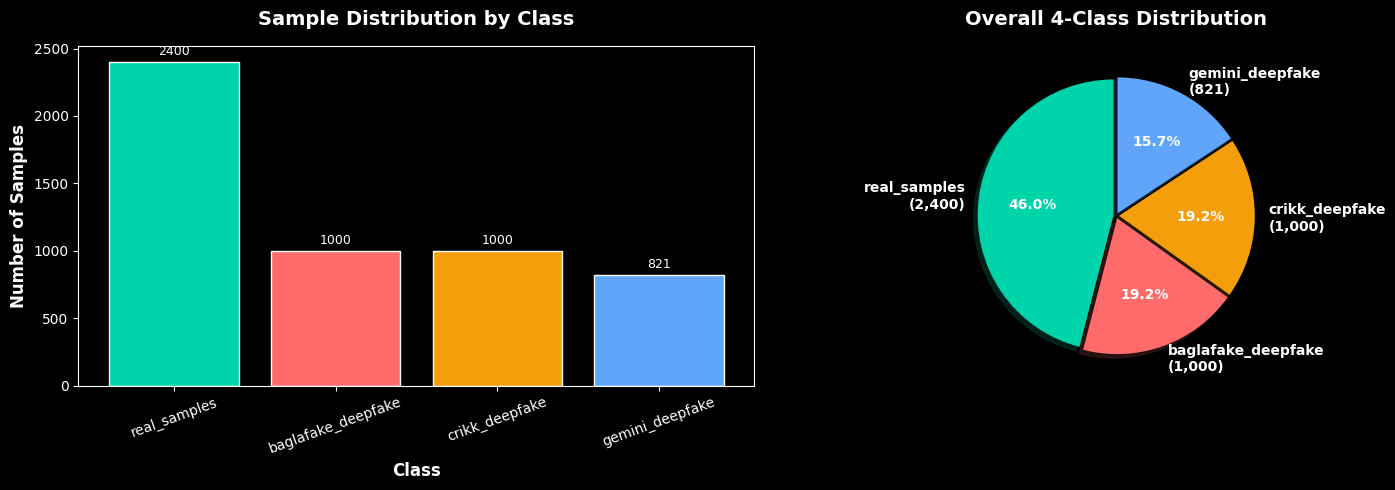

In [80]:
# Visualize dataset composition by class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = [len(all_files[c]) for c in CLASS_NAMES]
class_colors = [CLASS_COLORS[c] for c in CLASS_NAMES]

# Bar chart
bars = axes[0].bar(
    CLASS_NAMES,
    counts,
    color=class_colors,
    edgecolor='white'
    )
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Distribution by Class', fontsize=14, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=20)
axes[0].bar_label(bars, padding=3, fontsize=9)

# Pie chart
labels = [f"{c}\n({n:,})" for c, n in zip(CLASS_NAMES, counts)]
explode = [0.02] * len(CLASS_NAMES)
axes[1].pie(
    counts,
    labels=labels,
    colors=class_colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1].set_title('Overall 4-Class Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
save_fig('dataset_distribution.png')
plt.show()

---
## 3. Audio Statistics & Properties

Analyze key audio properties: duration, sample rate, amplitude statistics.


In [81]:
def get_audio_stats(file_path: Path) -> dict:
    """Extract audio statistics from a single file (supports wav/mp3)."""
    try:
        y, sr = librosa.load(file_path, sr=None, mono=True)
        duration = librosa.get_duration(y=y, sr=sr)
        return {
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'channels': 1,
            'samples': len(y),
            'rms': np.sqrt(np.mean(y**2)),
            'max_amplitude': np.max(np.abs(y)),
            'zero_crossings': np.sum(librosa.zero_crossings(y))
        }
    except Exception as e:
        return {'file': file_path.name, 'error': str(e)}


N_SAMPLES_PER_CLASS = 500

def sample_files(files_by_class: dict[str, list[Path]], n_per_class: int = N_SAMPLES_PER_CLASS):
    """Sample files from each class."""
    sampled = {}
    for class_name, files in files_by_class.items():
        n = min(n_per_class, len(files))
        sampled[class_name] = random.sample(files, n) if n > 0 else []
    return sampled

sampled_files = sample_files(all_files, N_SAMPLES_PER_CLASS)
for class_name in CLASS_NAMES:
    print(f"Sampled {len(sampled_files[class_name])} files for class '{class_name}'.")

Sampled 500 files for class 'real_samples'.
Sampled 500 files for class 'baglafake_deepfake'.
Sampled 500 files for class 'crikk_deepfake'.
Sampled 500 files for class 'gemini_deepfake'.


In [82]:
# Collect statistics per class
stats_rows = []

print("📈 Extracting audio statistics per class...")
for class_name in CLASS_NAMES:
    for f in tqdm(sampled_files[class_name], desc=f"{class_name} samples"):
        stats = get_audio_stats(f)
        if 'error' not in stats:
            stats['class_name'] = class_name
            stats_rows.append(stats)

stats_df = pd.DataFrame(stats_rows)
print(f"\n✅ Collected stats for {len(stats_df)} audio files.")
stats_df.head(10)

📈 Extracting audio statistics per class...


real_samples samples:   0%|          | 0/500 [00:00<?, ?it/s]

baglafake_deepfake samples:   0%|          | 0/500 [00:00<?, ?it/s]

crikk_deepfake samples:   0%|          | 0/500 [00:00<?, ?it/s]

gemini_deepfake samples:   0%|          | 0/500 [00:00<?, ?it/s]


✅ Collected stats for 2000 audio files.


,file,duration,sample_rate,channels,samples,rms,max_amplitude,zero_crossings,class_name
0,deepfake_data_mozilla__real_wav__common_voice_...,8.028000,32000,1,256896,0.162361,0.852325,11323,real_samples
1,deepfake_data_mozilla__real_wav__common_voice_...,6.048000,32000,1,193536,0.123756,0.853729,14325,real_samples
2,deepfake_data_sust__real_wav__06282.wav,9.657007,22050,1,212937,0.100002,0.344757,16385,real_samples
3,deepfake_data_sust__real_wav__03382.wav,8.545986,22050,1,188439,0.100002,0.434906,15255,real_samples
4,deepfake_data_sust__real_wav__02765.wav,4.835964,22050,1,106633,0.100004,0.366760,8207,real_samples
5,deepfake_data_news__real_wav__511.wav,4.551837,22050,1,100368,0.109887,0.647552,6156,real_samples
6,deepfake_data_mozilla__real_wav__common_voice_...,7.128000,32000,1,228096,0.045240,0.610260,13961,real_samples
7,deepfake_data_sust__real_wav__13555.wav,2.572018,22050,1,56713,0.100013,0.308624,3450,real_samples
8,deepfake_data_mozilla__real_wav__common_voice_...,6.408000,32000,1,205056,0.097712,0.816833,9385,real_samples
9,deepfake_data_sust__real_wav__10300.wav,5.298005,22050,1,116821,0.100010,0.507355,13186,real_samples


In [83]:
# Summary statistics by class
print("\n📊 AUDIO STATISTICS SUMMARY")
print("=" * 80)

for class_name in CLASS_NAMES:
    subset = stats_df[stats_df['class_name'] == class_name]
    if subset.empty:
        continue
    print(f"\n🎵 {class_name.upper()}:")
    print(f"  Count:             {len(subset):,}")
    print(f"  Sample Rate:       {subset['sample_rate'].mode().values[0]:,} Hz (mode)")
    print(f"  Duration (mean):   {subset['duration'].mean():.2f}s (σ={subset['duration'].std():.2f}s)")
    print(f"  Duration (range):  [{subset['duration'].min():.2f}s, {subset['duration'].max():.2f}s]")
    print(f"  RMS Energy (mean): {subset['rms'].mean():.4f}")
    print(f"  Max Amplitude:     {subset['max_amplitude'].mean():.4f}")

print("\n" + "=" * 80)


📊 AUDIO STATISTICS SUMMARY

🎵 REAL_SAMPLES:
  Count:             500
  Sample Rate:       22,050 Hz (mode)
  Duration (mean):   5.52s (σ=2.57s)
  Duration (range):  [1.00s, 13.71s]
  RMS Energy (mean): 0.1032
  Max Amplitude:     0.4884

🎵 BAGLAFAKE_DEEPFAKE:
  Count:             500
  Sample Rate:       22,050 Hz (mode)
  Duration (mean):   6.68s (σ=2.81s)
  Duration (range):  [1.52s, 38.13s]
  RMS Energy (mean): 0.0997
  Max Amplitude:     0.4811

🎵 CRIKK_DEEPFAKE:
  Count:             500
  Sample Rate:       24,000 Hz (mode)
  Duration (mean):   3.19s (σ=0.59s)
  Duration (range):  [1.63s, 5.02s]
  RMS Energy (mean): 0.0824
  Max Amplitude:     0.5064

🎵 GEMINI_DEEPFAKE:
  Count:             500
  Sample Rate:       24,000 Hz (mode)
  Duration (mean):   3.07s (σ=0.81s)
  Duration (range):  [1.09s, 5.33s]
  RMS Energy (mean): 0.1519
  Max Amplitude:     0.9104



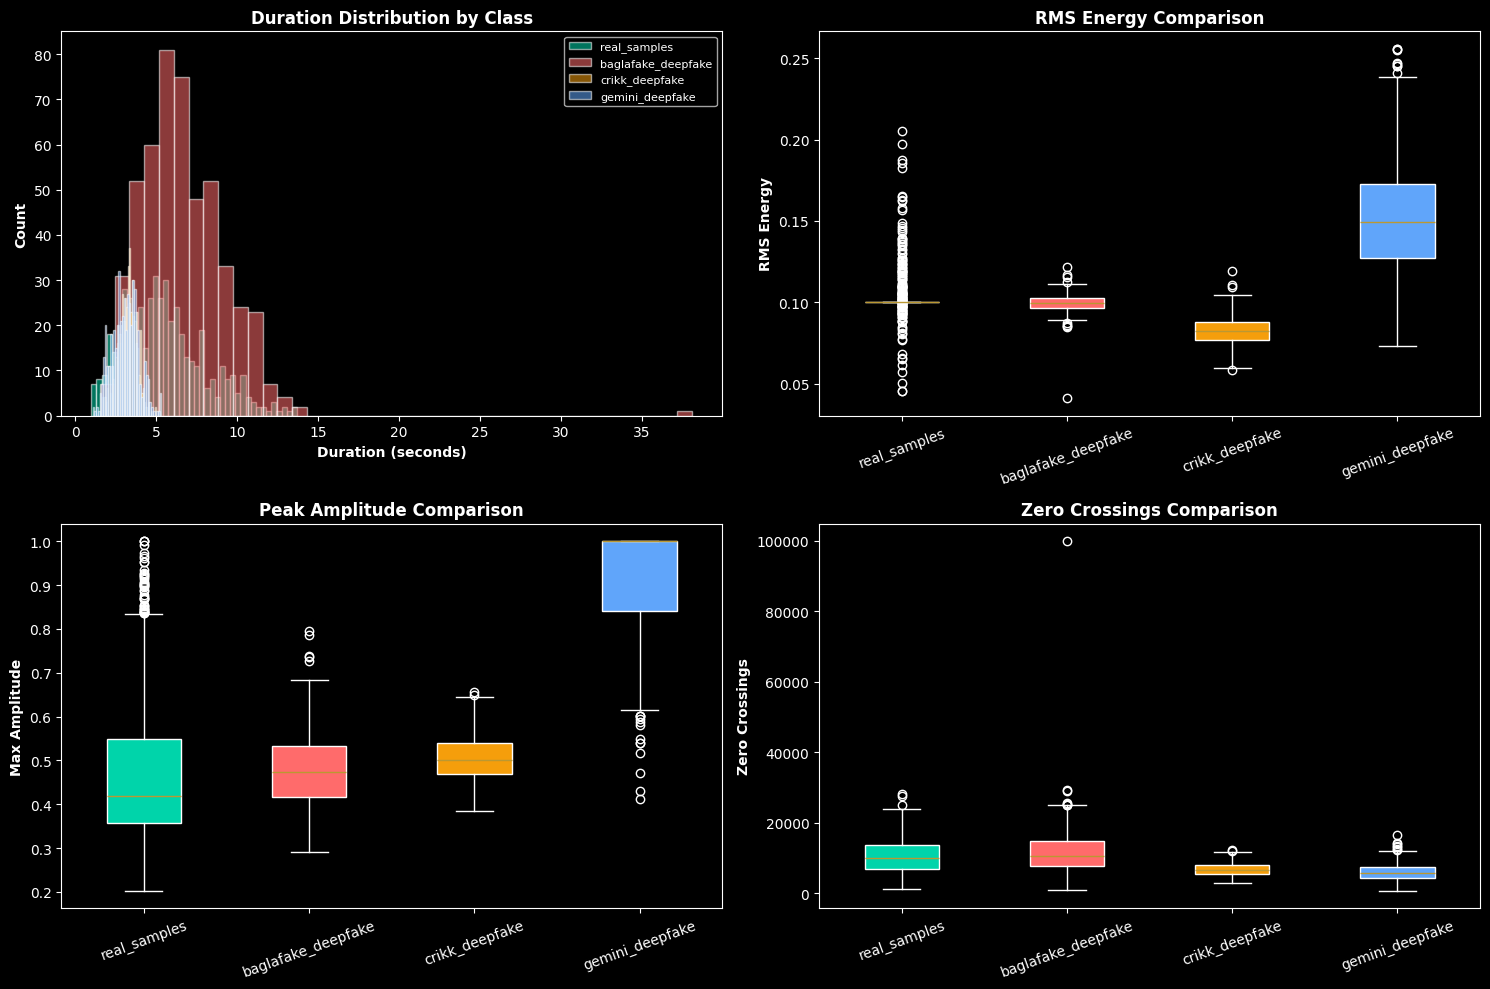

In [84]:
# Visualize duration and signal statistics across classes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Duration histogram by class
for class_name in CLASS_NAMES:
    subset = stats_df[stats_df['class_name'] == class_name]
    axes[0, 0].hist(
        subset['duration'],
        bins=40,
        alpha=0.55,
        label=class_name,
        color=CLASS_COLORS[class_name],
        edgecolor='white'
    )
axes[0, 0].set_xlabel('Duration (seconds)', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')
axes[0, 0].set_title('Duration Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=8)

# RMS boxplot
data_rms = [stats_df[stats_df['class_name'] == c]['rms'] for c in CLASS_NAMES]
bp = axes[0, 1].boxplot(data_rms, tick_labels=CLASS_NAMES, patch_artist=True)
for patch, c in zip(bp['boxes'], CLASS_NAMES):
    patch.set_facecolor(CLASS_COLORS[c])
axes[0, 1].set_ylabel('RMS Energy', fontweight='bold')
axes[0, 1].set_title('RMS Energy Comparison', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=20)

# Max amplitude boxplot
data_amp = [stats_df[stats_df['class_name'] == c]['max_amplitude'] for c in CLASS_NAMES]
bp2 = axes[1, 0].boxplot(data_amp, tick_labels=CLASS_NAMES, patch_artist=True)
for patch, c in zip(bp2['boxes'], CLASS_NAMES):
    patch.set_facecolor(CLASS_COLORS[c])
axes[1, 0].set_ylabel('Max Amplitude', fontweight='bold')
axes[1, 0].set_title('Peak Amplitude Comparison', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)

# Zero crossings boxplot
data_zc = [stats_df[stats_df['class_name'] == c]['zero_crossings'] for c in CLASS_NAMES]
bp3 = axes[1, 1].boxplot(data_zc, tick_labels=CLASS_NAMES, patch_artist=True)
for patch, c in zip(bp3['boxes'], CLASS_NAMES):
    patch.set_facecolor(CLASS_COLORS[c])
axes[1, 1].set_ylabel('Zero Crossings', fontweight='bold')
axes[1, 1].set_title('Zero Crossings Comparison', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
save_fig('audio_statistics.png')
plt.show()

---
## 4. Waveform Visualization

Compare real vs fake audio waveforms to identify visual differences.


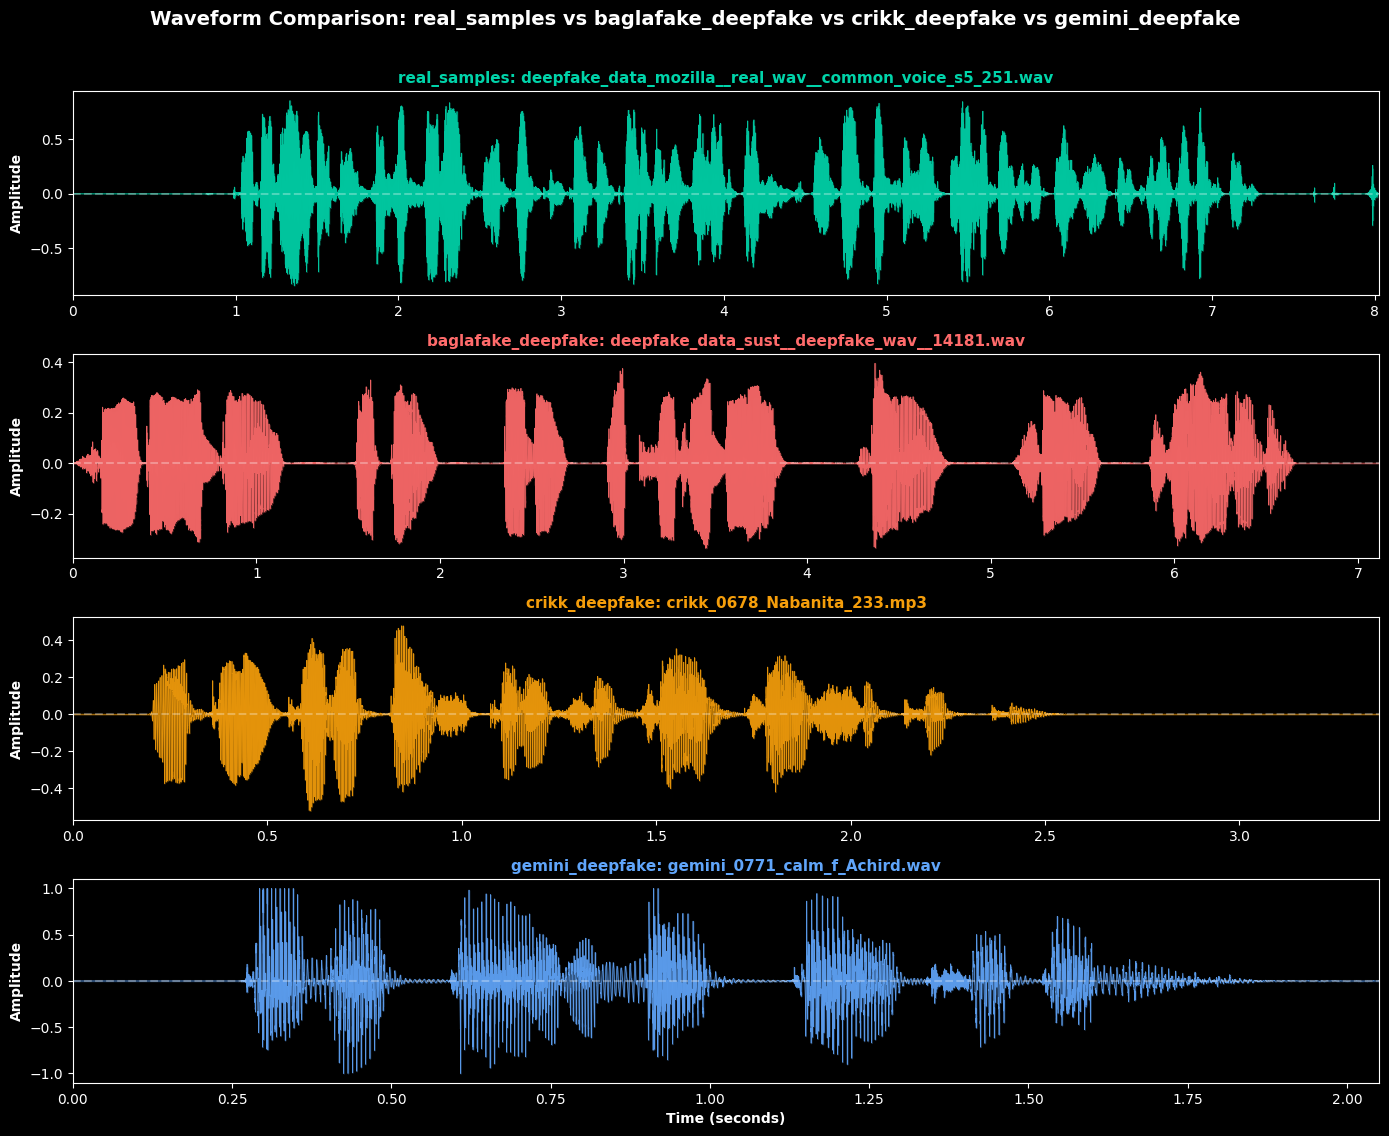

In [85]:
def plot_waveform_multiclass(sample_map: dict[str, Path], title: str = ""):

    """Plot stacked waveform comparison for real + fake classes."""

    class_order = ['real_samples', 'baglafake_deepfake', 'crikk_deepfake', 'gemini_deepfake']

    ordered_items = [(c, sample_map[c]) for c in class_order if c in sample_map]



    if len(ordered_items) < 2:

        raise ValueError("Need at least two classes to plot waveform comparison.")



    fig, axes = plt.subplots(len(ordered_items), 1, figsize=(14, 2.8 * len(ordered_items)), sharex=False)

    if len(ordered_items) == 1:

        axes = [axes]



    for idx, (class_name, file_path) in enumerate(ordered_items):

        y, sr = librosa.load(file_path, sr=None)

        t = np.arange(len(y)) / sr

        ax = axes[idx]

        ax.plot(t, y, color=CLASS_COLORS[class_name], linewidth=0.5, alpha=0.9)

        ax.fill_between(t, y, alpha=0.25, color=CLASS_COLORS[class_name])

        ax.set_ylabel('Amplitude', fontweight='bold')

        ax.set_title(

            f"{class_name}: {file_path.name}",

            fontsize=11,

            fontweight='bold',

            color=CLASS_COLORS[class_name]

        )

        ax.axhline(y=0, color='white', linestyle='--', alpha=0.3)

        if len(t) > 0:

            ax.set_xlim([0, t[-1]])



    axes[-1].set_xlabel('Time (seconds)', fontweight='bold')

    if title:

        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    plt.tight_layout()

    return fig





compare_classes = ['baglafake_deepfake', 'crikk_deepfake', 'gemini_deepfake']

sample_map = {'real_samples': sampled_files['real_samples'][0]}

for c in compare_classes:

    if c in sampled_files and len(sampled_files[c]) > 0:

        sample_map[c] = sampled_files[c][0]



# Keep these for downstream playback compatibility

sample_real = sample_map['real_samples']

fake_reference_class = next((c for c in compare_classes if c in sample_map), None)

if fake_reference_class is None:

    raise ValueError("No fake-class sample available for playback reference.")

sample_fake = sample_map[fake_reference_class]



fig = plot_waveform_multiclass(

    sample_map,

    "Waveform Comparison: real_samples vs baglafake_deepfake vs crikk_deepfake vs gemini_deepfake"

)

save_fig('waveform_multiclass_comparison.png')

save_fig('waveform_comparison.png')

plt.show()

In [86]:
# Listen to example samples
print("🎧 Listen to the samples:")
print("\n--- REAL SAMPLE (real_samples) ---")
display(Audio(sample_real))

print(f"\n--- FAKE SAMPLE ({fake_reference_class}) ---")
display(Audio(sample_fake))

🎧 Listen to the samples:

--- REAL SAMPLE (real_samples) ---



--- FAKE SAMPLE (baglafake_deepfake) ---


---
## 5. Spectral Analysis

Deep dive into spectrograms and mel-spectrograms to identify frequency-domain artifacts.


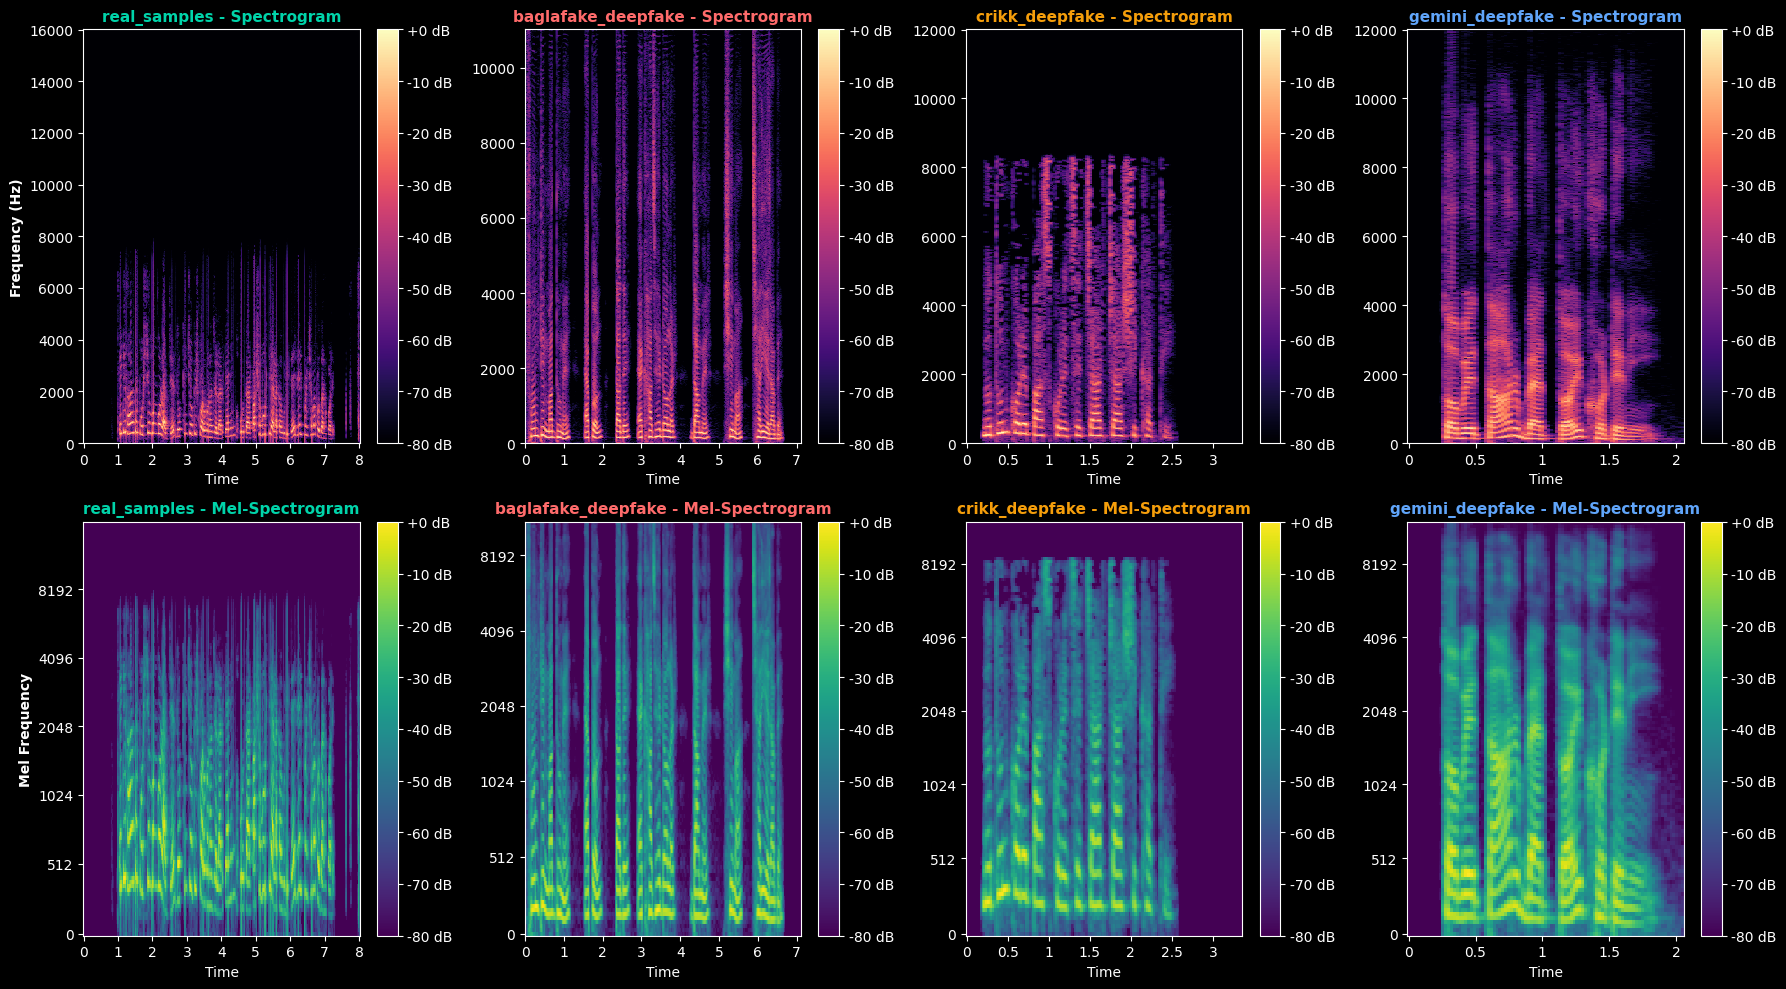

In [87]:
def plot_spectral_multiclass(sample_map: dict[str, Path], n_fft=2048, hop_length=512):

    """Plot spectrogram and mel-spectrogram for real + fake classes."""

    class_order = ['real_samples', 'baglafake_deepfake', 'crikk_deepfake', 'gemini_deepfake']

    selected_classes = [c for c in class_order if c in sample_map]



    if len(selected_classes) < 2:

        raise ValueError("Need at least two classes for spectral comparison.")



    fig, axes = plt.subplots(2, len(selected_classes), figsize=(4.5 * len(selected_classes), 10))

    if len(selected_classes) == 1:

        axes = np.array([[axes[0]], [axes[1]]])



    for col, class_name in enumerate(selected_classes):

        file_path = sample_map[class_name]

        y, sr = librosa.load(file_path, sr=None)



        # Standard spectrogram

        D = librosa.amplitude_to_db(

            np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)),

            ref=np.max

        )

        img1 = librosa.display.specshow(

            D,

            sr=sr,

            hop_length=hop_length,

            x_axis='time',

            y_axis='hz',

            ax=axes[0, col],

            cmap='magma'

        )

        axes[0, col].set_title(

            f"{class_name} - Spectrogram",

            fontsize=11,

            fontweight='bold',

            color=CLASS_COLORS[class_name]

        )

        axes[0, col].set_ylabel('Frequency (Hz)' if col == 0 else '', fontweight='bold')

        fig.colorbar(img1, ax=axes[0, col], format='%+2.0f dB')



        # Mel-spectrogram

        mel = librosa.feature.melspectrogram(

            y=y,

            sr=sr,

            n_fft=n_fft,

            hop_length=hop_length,

            n_mels=128

        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        img2 = librosa.display.specshow(

            mel_db,

            sr=sr,

            hop_length=hop_length,

            x_axis='time',

            y_axis='mel',

            ax=axes[1, col],

            cmap='viridis'

        )

        axes[1, col].set_title(

            f"{class_name} - Mel-Spectrogram",

            fontsize=11,

            fontweight='bold',

            color=CLASS_COLORS[class_name]

        )

        axes[1, col].set_ylabel('Mel Frequency' if col == 0 else '', fontweight='bold')

        fig.colorbar(img2, ax=axes[1, col], format='%+2.0f dB')



    plt.tight_layout()

    return fig





fig = plot_spectral_multiclass(sample_map)

save_fig('spectrogram_multiclass_comparison.png')

save_fig('spectrogram_comparison.png')

plt.show()

In [88]:
# High-frequency analysis per class
def analyze_high_frequency_content(file_path: Path, sr_target=22050, cutoff_hz=8000):
    """Analyze high-frequency content above a cutoff."""
    y, sr = librosa.load(file_path, sr=sr_target)

    D = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
    high_freq_idx = freqs >= cutoff_hz

    high_freq_energy = np.mean(D[high_freq_idx, :])
    total_energy = np.mean(D)
    ratio = high_freq_energy / total_energy if total_energy > 0 else 0

    return {
        'high_freq_energy': high_freq_energy,
        'total_energy': total_energy,
        'high_freq_ratio': ratio
    }


print("🔬 Analyzing high-frequency content (>8kHz) per class...\n")

hf_ratios_by_class = {}
for class_name in CLASS_NAMES:
    ratios = []
    for f in tqdm(sampled_files[class_name][:200], desc=f"{class_name} HF analysis"):
        ratios.append(analyze_high_frequency_content(f)['high_freq_ratio'])
    hf_ratios_by_class[class_name] = ratios
    print(f"{class_name:20s} mean={np.mean(ratios):.4f}, std={np.std(ratios):.4f}")

🔬 Analyzing high-frequency content (>8kHz) per class...



real_samples HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]

real_samples         mean=0.1121, std=0.0815


baglafake_deepfake HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]

baglafake_deepfake   mean=0.1269, std=0.0436


crikk_deepfake HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]

crikk_deepfake       mean=0.0227, std=0.0099


gemini_deepfake HF analysis:   0%|          | 0/200 [00:00<?, ?it/s]

gemini_deepfake      mean=0.2023, std=0.1071


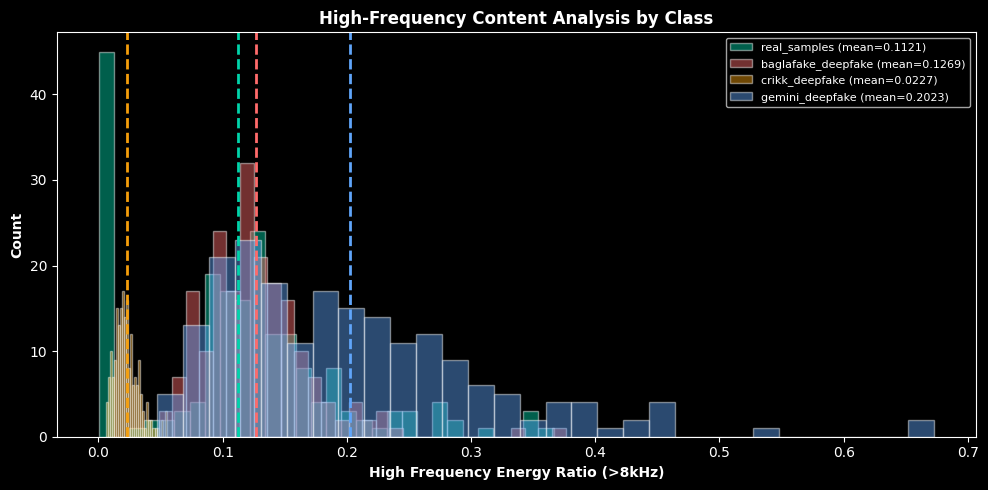

In [89]:
# Visualize high-frequency analysis by class
fig, ax = plt.subplots(figsize=(10, 5))

for class_name in CLASS_NAMES:
    ratios = hf_ratios_by_class[class_name]
    ax.hist(
        ratios,
        bins=30,
        alpha=0.45,
        label=f"{class_name} (mean={np.mean(ratios):.4f})",
        color=CLASS_COLORS[class_name],
        edgecolor='white'
    )
    ax.axvline(np.mean(ratios), color=CLASS_COLORS[class_name], linestyle='--', linewidth=2)

ax.set_xlabel('High Frequency Energy Ratio (>8kHz)', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('High-Frequency Content Analysis by Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
save_fig('high_frequency_analysis.png')
plt.show()

---
## 6. MFCC Feature Analysis

Extract and visualize MFCC features - the traditional baseline for audio classification.


In [90]:
def extract_mfcc_features(file_path: Path, n_mfcc=13, sr_target=22050):
    """Extract MFCC features and return a fixed-length per-file mean vector."""
    y, sr = librosa.load(file_path, sr=sr_target)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Defensive handling for malformed feature shapes
    if mfccs.ndim != 2 or mfccs.shape[0] == 0:
        return np.full(n_mfcc, np.nan, dtype=np.float32)

    feats = np.mean(mfccs, axis=1).astype(np.float32)
    if feats.shape[0] < n_mfcc:
        feats = np.pad(feats, (0, n_mfcc - feats.shape[0]), mode='constant', constant_values=np.nan)
    elif feats.shape[0] > n_mfcc:
        feats = feats[:n_mfcc]
    return feats


print("🎵 Extracting MFCC features per class...\n")
mfcc_by_class = {}
N_MFCC = 13

for class_name in CLASS_NAMES:
    class_feats = []
    for f in tqdm(sampled_files[class_name][:200], desc=f"{class_name} MFCC"):
        feats = extract_mfcc_features(f, n_mfcc=N_MFCC)
        if np.all(np.isnan(feats)):
            continue
        class_feats.append(feats)

    if len(class_feats) == 0:
        mfcc_by_class[class_name] = np.empty((0, N_MFCC), dtype=np.float32)
        print(f"{class_name:20s} -> no valid MFCC vectors")
    else:
        mfcc_by_class[class_name] = np.vstack(class_feats).astype(np.float32)
        print(f"{class_name:20s} -> shape {mfcc_by_class[class_name].shape}")

🎵 Extracting MFCC features per class...



real_samples MFCC:   0%|          | 0/200 [00:00<?, ?it/s]

real_samples         -> shape (200, 13)


baglafake_deepfake MFCC:   0%|          | 0/200 [00:00<?, ?it/s]

baglafake_deepfake   -> shape (200, 13)


crikk_deepfake MFCC:   0%|          | 0/200 [00:00<?, ?it/s]

crikk_deepfake       -> shape (200, 13)


gemini_deepfake MFCC:   0%|          | 0/200 [00:00<?, ?it/s]

gemini_deepfake      -> shape (200, 13)


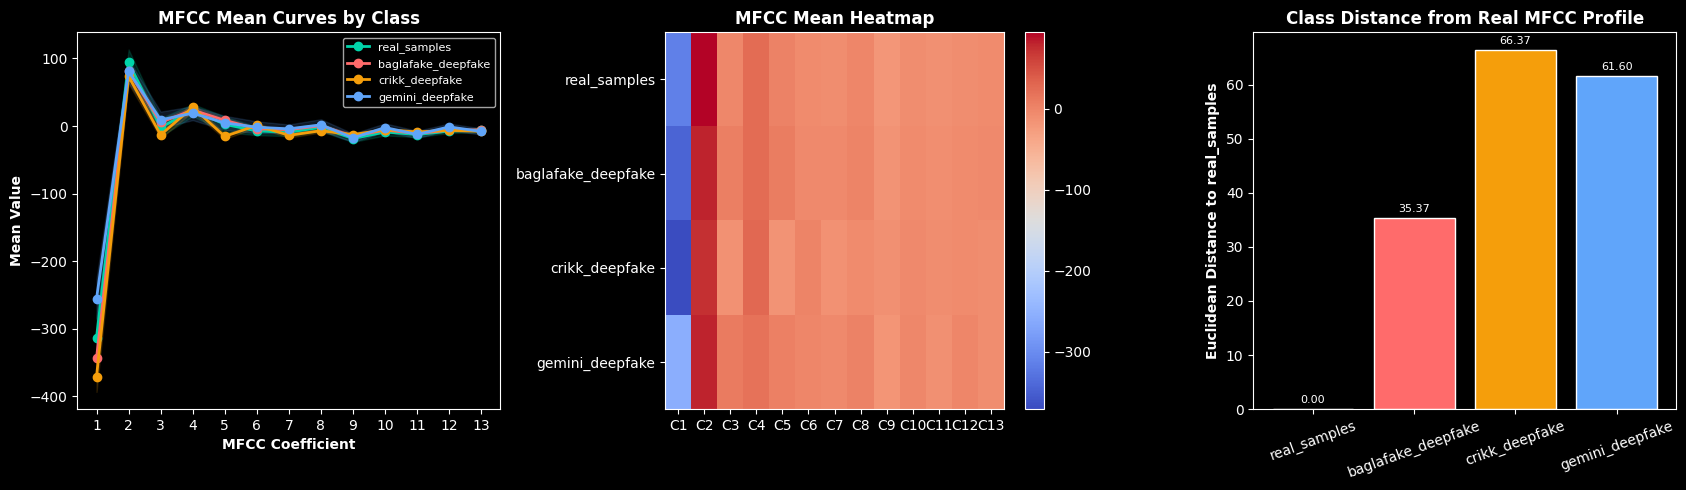

In [91]:
# MFCC comparison visualization (4-class)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

N_MFCC = 13
mfcc_indices = np.arange(1, N_MFCC + 1)

# Keep only classes with valid MFCC matrices of shape (n_samples, 13)
valid_classes = []
for class_name in CLASS_NAMES:
    arr = mfcc_by_class.get(class_name)
    if arr is None or arr.size == 0:
        continue
    if arr.ndim == 1:
        if arr.shape[0] == N_MFCC:
            arr = arr.reshape(1, -1)
        else:
            continue
    if arr.ndim == 2 and arr.shape[1] == N_MFCC:
        valid_classes.append(class_name)
        mfcc_by_class[class_name] = arr

if not valid_classes:
    raise ValueError("No valid MFCC feature matrices found for plotting.")

# 1) Mean MFCC curves per class
for class_name in valid_classes:
    class_arr = mfcc_by_class[class_name]
    means = np.nanmean(class_arr, axis=0)
    stds = np.nanstd(class_arr, axis=0)
    axes[0].plot(mfcc_indices, means, marker='o', linewidth=2, color=CLASS_COLORS[class_name], label=class_name)
    axes[0].fill_between(mfcc_indices, means - stds, means + stds, color=CLASS_COLORS[class_name], alpha=0.15)
axes[0].set_xlabel('MFCC Coefficient', fontweight='bold')
axes[0].set_ylabel('Mean Value', fontweight='bold')
axes[0].set_title('MFCC Mean Curves by Class', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_xticks(mfcc_indices)

# 2) Heatmap of class-wise MFCC means
heat_data = np.vstack([np.nanmean(mfcc_by_class[c], axis=0) for c in valid_classes])
im = axes[1].imshow(heat_data, aspect='auto', cmap='coolwarm')
axes[1].set_yticks(np.arange(len(valid_classes)))
axes[1].set_yticklabels(valid_classes)
axes[1].set_xticks(np.arange(N_MFCC))
axes[1].set_xticklabels([f'C{i}' for i in range(1, N_MFCC + 1)])
axes[1].set_title('MFCC Mean Heatmap', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=axes[1])

# 3) Distance from real class mean (when available)
if 'real_samples' in valid_classes:
    real_mean = np.nanmean(mfcc_by_class['real_samples'], axis=0)
    distances = []
    for class_name in valid_classes:
        cls_mean = np.nanmean(mfcc_by_class[class_name], axis=0)
        distances.append(np.linalg.norm(cls_mean - real_mean))

    bars = axes[2].bar(valid_classes, distances, color=[CLASS_COLORS[c] for c in valid_classes], edgecolor='white')
    axes[2].set_ylabel('Euclidean Distance to real_samples', fontweight='bold')
    axes[2].set_title('Class Distance from Real MFCC Profile', fontsize=12, fontweight='bold')
    axes[2].tick_params(axis='x', rotation=20)
    axes[2].bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'real_samples not available\nfor distance comparison',
                 ha='center', va='center', fontweight='bold')

plt.tight_layout()
save_fig('mfcc_analysis.png')
plt.show()

🔮 Computing t-SNE embedding of MFCC features...


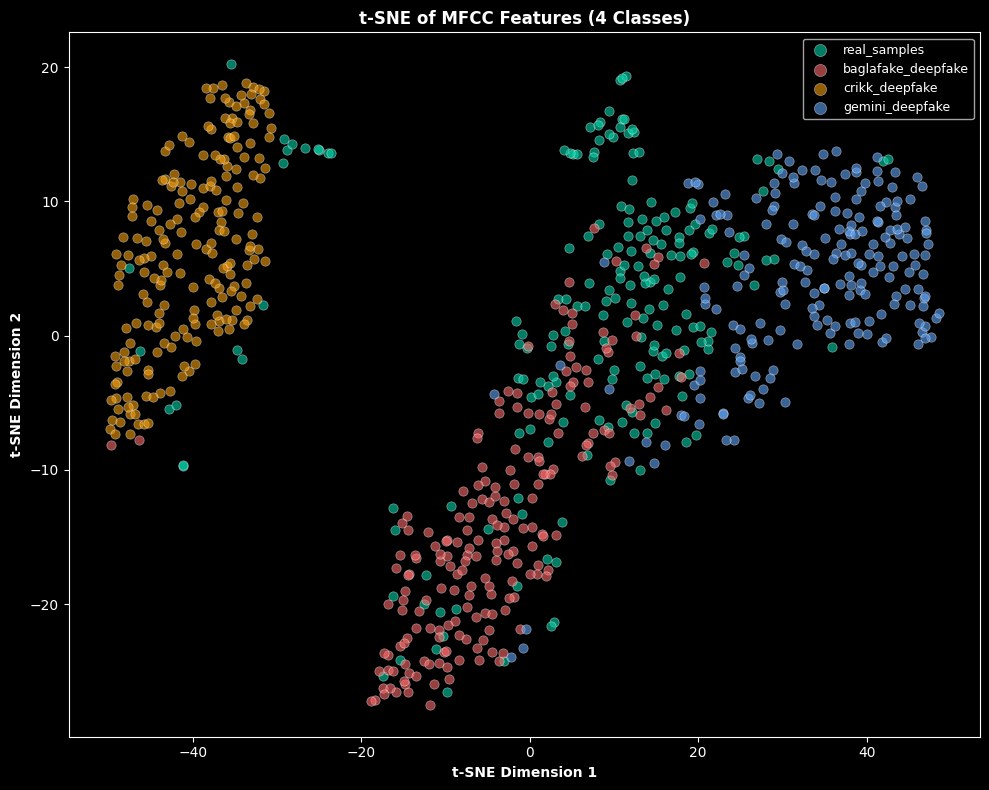


💡 Rendered t-SNE for 4 classes with valid MFCC vectors.


In [92]:
# t-SNE visualization of MFCC features (4-class)
from sklearn.manifold import TSNE

print("🔮 Computing t-SNE embedding of MFCC features...")

valid_classes = [c for c in CLASS_NAMES if c in mfcc_by_class and mfcc_by_class[c].size > 0]
if len(valid_classes) < 2:
    raise ValueError("Need at least 2 classes with valid MFCC vectors for t-SNE.")

X = np.vstack([mfcc_by_class[c] for c in valid_classes])
labels = []
for c in valid_classes:
    labels.extend([c] * len(mfcc_by_class[c]))
labels = np.array(labels)

# Keep perplexity valid for smaller sample sizes
perplexity = min(30, max(5, len(X) // 4))
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, max_iter=1000)
X_embedded = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
for class_name in valid_classes:
    mask = labels == class_name
    ax.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        c=CLASS_COLORS[class_name],
        label=class_name,
        alpha=0.6,
        s=45,
        edgecolors='white',
        linewidth=0.4
    )

ax.set_xlabel('t-SNE Dimension 1', fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold')
ax.set_title('t-SNE of MFCC Features (4 Classes)', fontsize=12, fontweight='bold')
ax.legend(markerscale=1.3, fontsize=9)

plt.tight_layout()
save_fig('tsne_mfcc.png')
plt.show()

print(f"\n💡 Rendered t-SNE for {len(valid_classes)} classes with valid MFCC vectors.")

---
## 7. Dataset Balance & Distribution Analysis


In [93]:
# Create comprehensive dataset manifest (4-class)
def create_dataset_manifest(files_by_class: dict[str, list[Path]]) -> pd.DataFrame:
    records = []
    class_to_id = {name: idx for idx, name in enumerate(CLASS_NAMES)}

    for class_name, files in files_by_class.items():
        for f in files:
            records.append({
                'file_path': str(f),
                'filename': f.name,
                'class_name': class_name,
                'class_id': class_to_id[class_name],
                'is_fake': 0 if class_name == 'real_samples' else 1
            })

    return pd.DataFrame(records)


manifest_df = create_dataset_manifest(all_files)
print(f"📋 Created manifest with {len(manifest_df):,} samples")
print("\nClass distribution:")
print(manifest_df['class_name'].value_counts())

📋 Created manifest with 5,221 samples

Class distribution:
class_name
real_samples          2400
baglafake_deepfake    1000
crikk_deepfake        1000
gemini_deepfake        821
Name: count, dtype: int64



📊 Class Count Table:
class_name
real_samples          2400
baglafake_deepfake    1000
crikk_deepfake        1000
gemini_deepfake        821
Name: count, dtype: int64


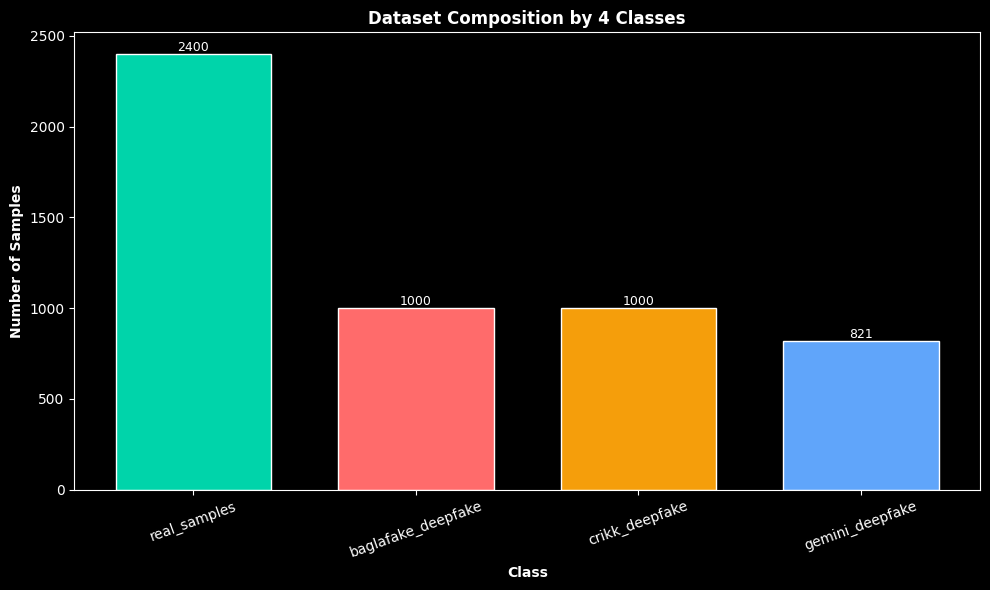

In [94]:
# Class distribution table and plot
class_counts = manifest_df['class_name'].value_counts().reindex(CLASS_NAMES)
print("\n📊 Class Count Table:")
print(class_counts)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[CLASS_COLORS[c] for c in class_counts.index],
    edgecolor='white',
    width=0.7
)

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Number of Samples', fontweight='bold')
ax.set_title('Dataset Composition by 4 Classes', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.bar_label(bars, fmt='%d', fontsize=9)

plt.tight_layout()
save_fig('source_label_distribution.png')
plt.show()

---
## 8. Stratified Train/Val/Test Split (70/15/15)

Create balanced splits ensuring proportional representation from each source and label.


In [95]:
# Stratified split by class_name: 70/15/15
train_df, temp_df = train_test_split(
    manifest_df,
    test_size=0.30,
    stratify=manifest_df['class_name'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class_name'],
    random_state=SEED
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print("📊 STRATIFIED DATA SPLIT SUMMARY")
print("=" * 50)
print(f"  Training:   {len(train_df):6,} samples ({100*len(train_df)/len(manifest_df):.1f}%)")
print(f"  Validation: {len(val_df):6,} samples ({100*len(val_df)/len(manifest_df):.1f}%)")
print(f"  Test:       {len(test_df):6,} samples ({100*len(test_df)/len(manifest_df):.1f}%)")
print("=" * 50)
print(f"  Total:      {len(manifest_df):6,} samples")

📊 STRATIFIED DATA SPLIT SUMMARY
  Training:    3,654 samples (70.0%)
  Validation:    783 samples (15.0%)
  Test:          784 samples (15.0%)
  Total:       5,221 samples


In [96]:
# Verify class stratification
print("\n🔍 STRATIFICATION VERIFICATION")
print("=" * 70)

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{split_name} Set Distribution:")
    print(split_df['class_name'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))


🔍 STRATIFICATION VERIFICATION

Train Set Distribution:
class_name
real_samples          1680
baglafake_deepfake     700
crikk_deepfake         700
gemini_deepfake        574
Name: count, dtype: int32

Val Set Distribution:
class_name
real_samples          360
baglafake_deepfake    150
crikk_deepfake        150
gemini_deepfake       123
Name: count, dtype: int32

Test Set Distribution:
class_name
real_samples          360
baglafake_deepfake    150
crikk_deepfake        150
gemini_deepfake       124
Name: count, dtype: int32


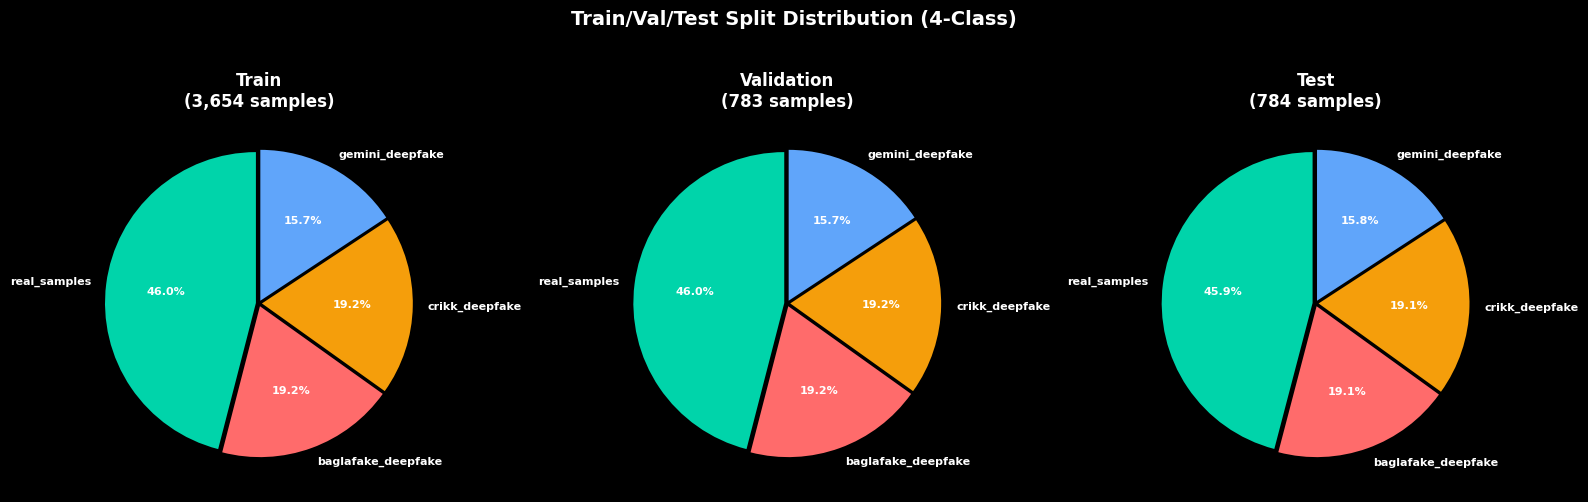

In [97]:
# Visualize split distribution by class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    ax = axes[idx]
    counts = split_df['class_name'].value_counts().reindex(CLASS_NAMES).fillna(0)

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=CLASS_NAMES,
        colors=[CLASS_COLORS[c] for c in CLASS_NAMES],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.02] * len(CLASS_NAMES),
        textprops={'fontweight': 'bold', 'fontsize': 8}
    )
    ax.set_title(f'{split_name}\n({len(split_df):,} samples)', fontsize=12, fontweight='bold')

fig.suptitle('Train/Val/Test Split Distribution (4-Class)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('split_distribution.png')
plt.show()

---
## 9. Data Export for Training Pipeline


In [98]:
# Combine splits into final manifest
final_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)
final_manifest = final_manifest[
    ['file_path', 'filename', 'class_name', 'class_id', 'is_fake', 'split']
]

print(f"📋 Final manifest shape: {final_manifest.shape}")
final_manifest.head(10)

📋 Final manifest shape: (5221, 6)


,file_path,filename,class_name,class_id,is_fake,split
0,Data\gemini_deepfake\gemini_0562_calm_m_Iapetu...,gemini_0562_calm_m_Iapetus.wav,gemini_deepfake,3,1,train
1,Data\baglafake_deepfake\deepfake_data_sust__de...,deepfake_data_sust__deepfake_wav__10103.wav,baglafake_deepfake,1,1,train
2,Data\crikk_deepfake\crikk_0443_Nabanita_540.mp3,crikk_0443_Nabanita_540.mp3,crikk_deepfake,2,1,train
3,Data\real_samples\deepfake_data_mozilla__real_...,deepfake_data_mozilla__real_wav__common_voice_...,real_samples,0,0,train
4,Data\real_samples\deepfake_data_sust__real_wav...,deepfake_data_sust__real_wav__14589.wav,real_samples,0,0,train
5,Data\real_samples\deepfake_data_sust__real_wav...,deepfake_data_sust__real_wav__03126.wav,real_samples,0,0,train
6,Data\crikk_deepfake\crikk_0258_Nabanita_359.mp3,crikk_0258_Nabanita_359.mp3,crikk_deepfake,2,1,train
7,Data\real_samples\deepfake_data_news__real_wav...,deepfake_data_news__real_wav__916.wav,real_samples,0,0,train
8,Data\baglafake_deepfake\deepfake_data_sust__de...,deepfake_data_sust__deepfake_wav__3312.wav,baglafake_deepfake,1,1,train
9,Data\crikk_deepfake\crikk_0085_Nabanita_81.mp3,crikk_0085_Nabanita_81.mp3,crikk_deepfake,2,1,train


In [99]:
# Export manifest files
OUTPUT_DIR = Path('./Manifest')
OUTPUT_DIR.mkdir(exist_ok=True)

final_manifest.to_csv(OUTPUT_DIR / 'dataset_manifest.csv', index=False)
train_df[['file_path', 'filename', 'class_name', 'class_id', 'is_fake']].to_csv(OUTPUT_DIR / 'train_manifest.csv', index=False)
val_df[['file_path', 'filename', 'class_name', 'class_id', 'is_fake']].to_csv(OUTPUT_DIR / 'val_manifest.csv', index=False)
test_df[['file_path', 'filename', 'class_name', 'class_id', 'is_fake']].to_csv(OUTPUT_DIR / 'test_manifest.csv', index=False)

print("✅ Exported manifests:")
print(f"  - {OUTPUT_DIR / 'dataset_manifest.csv'}")
print(f"  - {OUTPUT_DIR / 'train_manifest.csv'}")
print(f"  - {OUTPUT_DIR / 'val_manifest.csv'}")
print(f"  - {OUTPUT_DIR / 'test_manifest.csv'}")

✅ Exported manifests:
  - Manifest\dataset_manifest.csv
  - Manifest\train_manifest.csv
  - Manifest\val_manifest.csv
  - Manifest\test_manifest.csv


In [100]:
# Summary statistics for the multiclass pipeline
print("\n" + "=" * 70)
print("📋 FINAL DATASET SUMMARY FOR TRAINING PIPELINE")
print("=" * 70)

class_counts = final_manifest['class_name'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)

print("Dataset Statistics:")
print(f"  - Total samples: {len(final_manifest):,}")
for class_name in CLASS_NAMES:
    print(f"  - {class_name}: {class_counts[class_name]:,}")

print("\nSplit Distribution:")
print(f"  - Train: {len(train_df):,} ({100*len(train_df)/len(final_manifest):.1f}%)")
print(f"  - Val:   {len(val_df):,} ({100*len(val_df)/len(final_manifest):.1f}%)")
print(f"  - Test:  {len(test_df):,} ({100*len(test_df)/len(final_manifest):.1f}%)")

print("\nSaved Plots:")
print(f"  - Visualization directory: {VISUALIZATION_DIR.resolve()}")

print("\nNote:")
print("  - The notebook now treats each dataset folder as an independent class")
print("    (1 real class + 3 deepfake classes).")
print("=" * 70)


📋 FINAL DATASET SUMMARY FOR TRAINING PIPELINE
Dataset Statistics:
  - Total samples: 5,221
  - real_samples: 2,400
  - baglafake_deepfake: 1,000
  - crikk_deepfake: 1,000
  - gemini_deepfake: 821

Split Distribution:
  - Train: 3,654 (70.0%)
  - Val:   783 (15.0%)
  - Test:  784 (15.0%)

Saved Plots:
  - Visualization directory: F:\ML Project\Bangla Audio Deepfake Detection\Data Augmentation\Visualization

Note:
  - The notebook now treats each dataset folder as an independent class
    (1 real class + 3 deepfake classes).


---
## Next Steps

The preprocessing notebook is now configured for a 4-class setup from the `Data` directory:
- `real_samples`
- `baglafake_deepfake`
- `crikk_deepfake`
- `gemini_deepfake`

Generated plots are saved under the parent `Visualization` directory.

Suggested next steps:
1. Train a 4-class classifier and evaluate per-class confusion matrix.
2. Add class weighting or focal loss if class counts are imbalanced.
3. Export a binary view (`is_fake`) only when needed for binary experiments.